In [2]:
from helpers import ObserveAttentionHelper

import matplotlib.pyplot as plt
import torch
import numpy as np
import random
from tqdm import tqdm
import pandas as pd;

/home/mohsen/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/mohsen/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
model_name = "Qwen/Qwen3-8B"
max_new_tokens = 5000
prompt = """
Think carefully through this problem before answering.
A 5-digit number has the following properties:

The sum of its digits is 21.

The number is divisible by 9.

The first digit is twice the last digit.

All digits are distinct.

What is one possible number? The prompt "Explain your reasoning step by step." is asking you to provide a detailed explanation of how you arrived at the solution to the problem presented in the prompt. This typically involves breaking down the problem into smaller steps, showing your thought process, and explaining the logic behind each step you took to solve the problem. By providing a step-by-step explanation, you can help others understand your reasoning and follow the process you used to arrive at the solution.
Explain your reasoning step by step.
"""
observer = ObserveAttentionHelper(model_name, max_new_tokens=max_new_tokens)
observer.run_model(prompt)

Loading model: Qwen/Qwen3-8B


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 399/399 [00:01<00:00, 251.14it/s, Materializing param=model.norm.weight]                              


Model loaded on cuda
Prompt length: 64 tokens
Generating 5000 tokens...


100%|█████████▉| 5000/5001 [03:20<00:00, 24.95it/s]


Generation complete. Total tokens generated: 5000
Layers captured: 36


'\nThink carefully through this problem before answering.\nA 5-digit number has the following properties:\n\nThe sum of its digits is 21.\n\nThe number is divisible by 9.\n\nThe first digit is twice the last digit.\n\nAll digits are distinct.\n\nWhat is one possible number? Explain your reasoning step by step.\nOkay, let\'s try to figure out this 5-digit number problem. So, the number has to satisfy four conditions: the sum of its digits is 21, it\'s divisible by 9, the first digit is twice the last digit, and all digits are distinct. Hmm, let me break this down step by step.\n\nFirst, I remember that a number is divisible by 9 if the sum of its digits is a multiple of 9. Wait, the problem says the sum of its digits is 21. But 21 divided by 9 is 2 with a remainder of 3. That means 21 isn\'t a multiple of 9. Wait, that seems conflicting. If the number is divisible by 9, then the sum of its digits must be a multiple of 9. But the problem says the sum is 21. Is there a mistake here?\n\nHo

In [ ]:
# observer.save(f"{model_name.split('/')[-1]}_attention_data_{max_new_tokens}.pt")

Data saved to Qwen3-8B_attention_data_5000.pt


In [6]:
attn_info = observer.get_attention_info()
attn_info

{'num_layers': 36,
 'num_q_heads': 32,
 'num_kv_heads': 8,
 'head_dim': 128,
 'prompt_length': 64,
 'num_generated': 5000,
 'total_tokens': 5064,
 'uses_gqa': True}

In [74]:
from sklearn.cluster import KMeans


def tail_bulk(x):
    x_np = x.detach().cpu().numpy().reshape(-1, 1)

    km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(x_np)
    labels = km.labels_
    centers = km.cluster_centers_.flatten()

    tail_cluster = np.argmax(centers)  # the "high value" cluster
    tail_size = np.count_nonzero(labels == tail_cluster)

    tail_mass = x_np[labels == tail_cluster].sum() / x_np.sum()

    return tail_size, tail_mass


def snr(x, k=16):
    x_np = x.detach().cpu().numpy()
    topk_indices = np.argpartition(x_np, -k)[-k:]
    topk_values = x_np[topk_indices]

    mean_topk = topk_values.mean()
    mean_rest = (x_np.sum() - topk_values.sum()) / (len(x_np) - k)
    std_rest = np.sqrt(((x_np - mean_rest) ** 2).sum() / (len(x_np) - k))

    return (mean_topk - mean_rest) / std_rest if std_rest > 0 else float("inf")

In [75]:
layers = attn_info["num_layers"]
tokens = attn_info["num_generated"]
heads = attn_info["num_q_heads"]

results = {
    "token": [],
    "size": [],
    "tail_size": [],
    "tail_mass": [],
    "snr": [],
}

for token in tqdm(list(range(tokens))[::10], desc="Processing tokens"):
    stats = observer.get_stats_at_token(token)[20]
    scores = None
    for head in range(heads):
        if scores is None:
            scores = stats[head]["scores"]
        else:
            scores += stats[head]["scores"]
    scores = scores / heads

    # calculate the right skew
    tail_size, tail_mass = tail_bulk(scores)
    snr_val = snr(scores)
    results["token"].append(token)
    results["size"].append(scores.shape[0])
    results["tail_size"].append(tail_size)
    results["tail_mass"].append(tail_mass)
    results["snr"].append(snr_val)

results = pd.DataFrame(results)
results.to_csv("tail_size_over_time.csv", index=False)

Processing tokens: 100%|██████████| 500/500 [08:09<00:00,  1.02it/s]


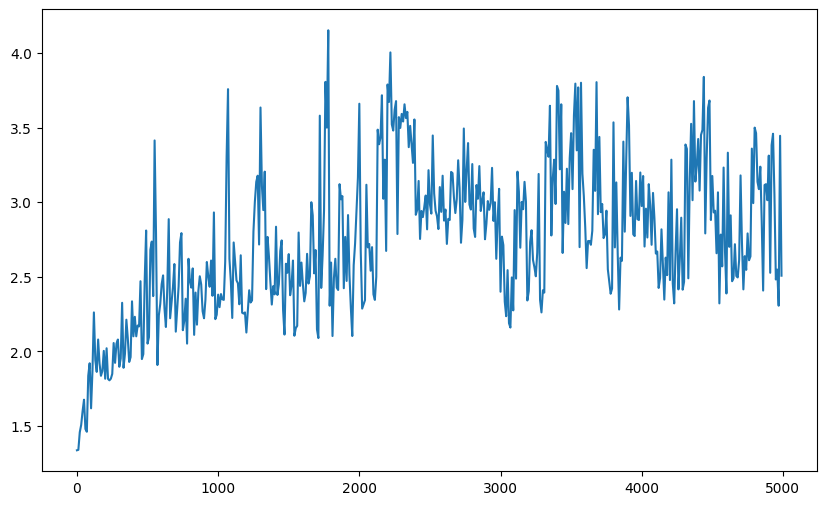

In [90]:
plt.figure(figsize=(10, 6))
plt.plot(
    results["token"],
    # results["tail_size"] / results["size"]
    results["snr"],
    # label="Tail Size (scaled)",÷
)

In [101]:
# get top k of tail_size / size
results["tail_ratio"] = results["tail_size"] / results["size"]
top_k = results.nlargest(16, "tail_ratio")
least_k = results.nsmallest(16, "tail_ratio")

# results["snr"] = results["snr"].astype("float32")  # or float64
# top_k = results.nlargest(16, "snr")
# least_k = results.nsmallest(16, "snr")

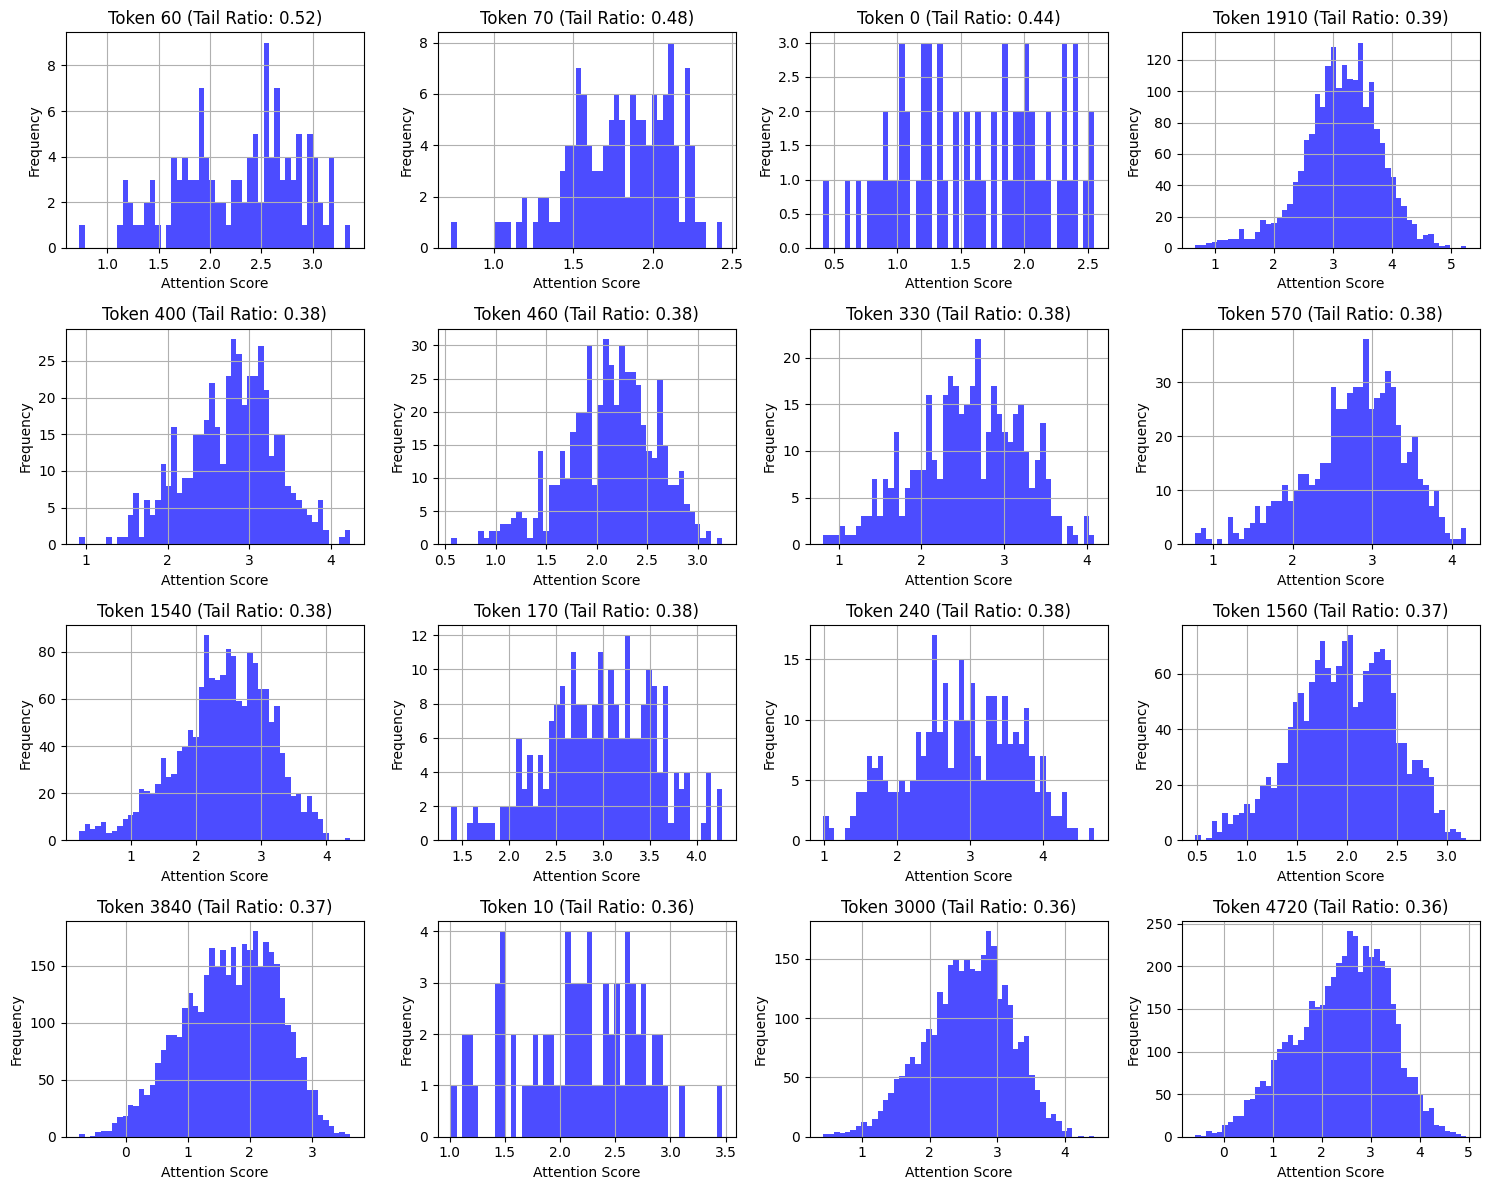

In [79]:
fig, axes = plt.subplots(4, 4, figsize=(15, 12))

for i, token in enumerate(top_k["token"]):
    stats = observer.get_stats_at_token(token)[20]
    scores = None
    for head in range(heads):
        if scores is None:
            scores = stats[head]["scores"]
        else:
            scores += stats[head]["scores"]
    scores = scores / heads

    axes[i // 4, i % 4].hist(scores.cpu().numpy(), bins=50, color="blue", alpha=0.7)
    axes[i // 4, i % 4].set_title(
        f"Token {token} (Tail Ratio: {results.loc[results['token'] == token, 'tail_ratio'].values[0]:.2f})"
    )
    axes[i // 4, i % 4].set_xlabel("Attention Score")
    axes[i // 4, i % 4].set_ylabel("Frequency")
    axes[i // 4, i % 4].grid()
plt.tight_layout()
plt.show()

In [111]:
for i, token in enumerate(top_k["token"]):
    tail_size_over_size = results.loc[results["token"] == token, "tail_ratio"].values[0]
    print(
        f"Token ID:{token} \t| tail_ratio: {tail_size_over_size:.2f} |",
        end=" ",
    )
    # print the neighboring tokens
    for offset in range(-1, 6):
        neighbor_token = token + offset
        if 0 <= neighbor_token < tokens:
            print(f"{observer.get_token_string(neighbor_token)}", end=" ")
    print()

Token ID:60 	| tail_ratio: 0.52 |  let  me  break  this  down  step  by 
Token ID:70 	| tail_ratio: 0.48 | ,  I  remember  that  a  number  is 
Token ID:0 	| tail_ratio: 0.44 | Okay ,  let 's  try  to 
Token ID:1910 	| tail_ratio: 0.39 |  the  problem  had  a  typo ,  and 
Token ID:400 	| tail_ratio: 0.38 |  the  number  cannot  be  divisible  by   
Token ID:460 	| tail_ratio: 0.38 |  need  to  find  a  number  that  satisfies 
Token ID:330 	| tail_ratio: 0.38 | .  The  sum  of  digits  is   
Token ID:570 	| tail_ratio: 0.38 |  the  problem ,  the  number  is  divisible 
Token ID:1540 	| tail_ratio: 0.38 |  the  assumption  that  there  is  a  solution 
Token ID:170 	| tail_ratio: 0.38 |  the  problem  says  the  sum  is   
Token ID:240 	| tail_ratio: 0.38 |  the  sum  of  its  digits  must  be 
Token ID:1560 	| tail_ratio: 0.37 |  let  me  check  again .  Let  me 
Token ID:3840 	| tail_ratio: 0.37 |  of   2 1 .  Then , 
Token ID:10 	| tail_ratio: 0.36 |   5 -digit  number  problem .  

In [114]:
for i, token in enumerate(least_k["token"]):
    tail_size_over_size = results.loc[results["token"] == token, "tail_ratio"].values[0]
    print(
        f"Token ID:{token} \t| tail_ratio: {tail_size_over_size:.2f} |",
        end=" ",
    )
    # print the neighboring tokens
    for offset in range(-1, 6):
        neighbor_token = token + offset
        if 0 <= neighbor_token < tokens:
            print(f"{observer.get_token_string(neighbor_token)}", end=" ")
    print()

Token ID:550 	| tail_ratio: 0.08 |  twice  the  last  digit .

 All  digits 
Token ID:2320 	| tail_ratio: 0.10 | 0 ,  so  D 5  cannot  be 
Token ID:1060 	| tail_ratio: 0.11 | 0 ?  For  example ,  if  it 
Token ID:2230 	| tail_ratio: 0.11 |  the  first  digit  of  a   5 
Token ID:2200 	| tail_ratio: 0.11 | ,  let 's  consider  possible  values  for 
Token ID:2260 	| tail_ratio: 0.13 | .  Therefore ,  D 5  can  be 
Token ID:2220 	| tail_ratio: 0.13 |  between   1  and   9  ( 
Token ID:1330 	| tail_ratio: 0.13 | 9 =   3 6 ,  which 
Token ID:2330 	| tail_ratio: 0.13 |  D 1  would  be   0 . 
Token ID:2520 	| tail_ratio: 0.13 | 5 = 2 .  Sum  of  D 
Token ID:2000 	| tail_ratio: 0.13 |  cannot  be  zero .  Also ,  all 
Token ID:2370 	| tail_ratio: 0.13 |  pairs  for  ( D 1 ,  D 
Token ID:2210 	| tail_ratio: 0.13 |  Since  D 1  is  a  digit , 
Token ID:1260 	| tail_ratio: 0.14 |  sum  is   9 + 9 + 
Token ID:2300 	| tail_ratio: 0.14 | 5  can  be   0 , 1 
Token ID:2340 	| tail_ratio: 0.14 | 5  ca

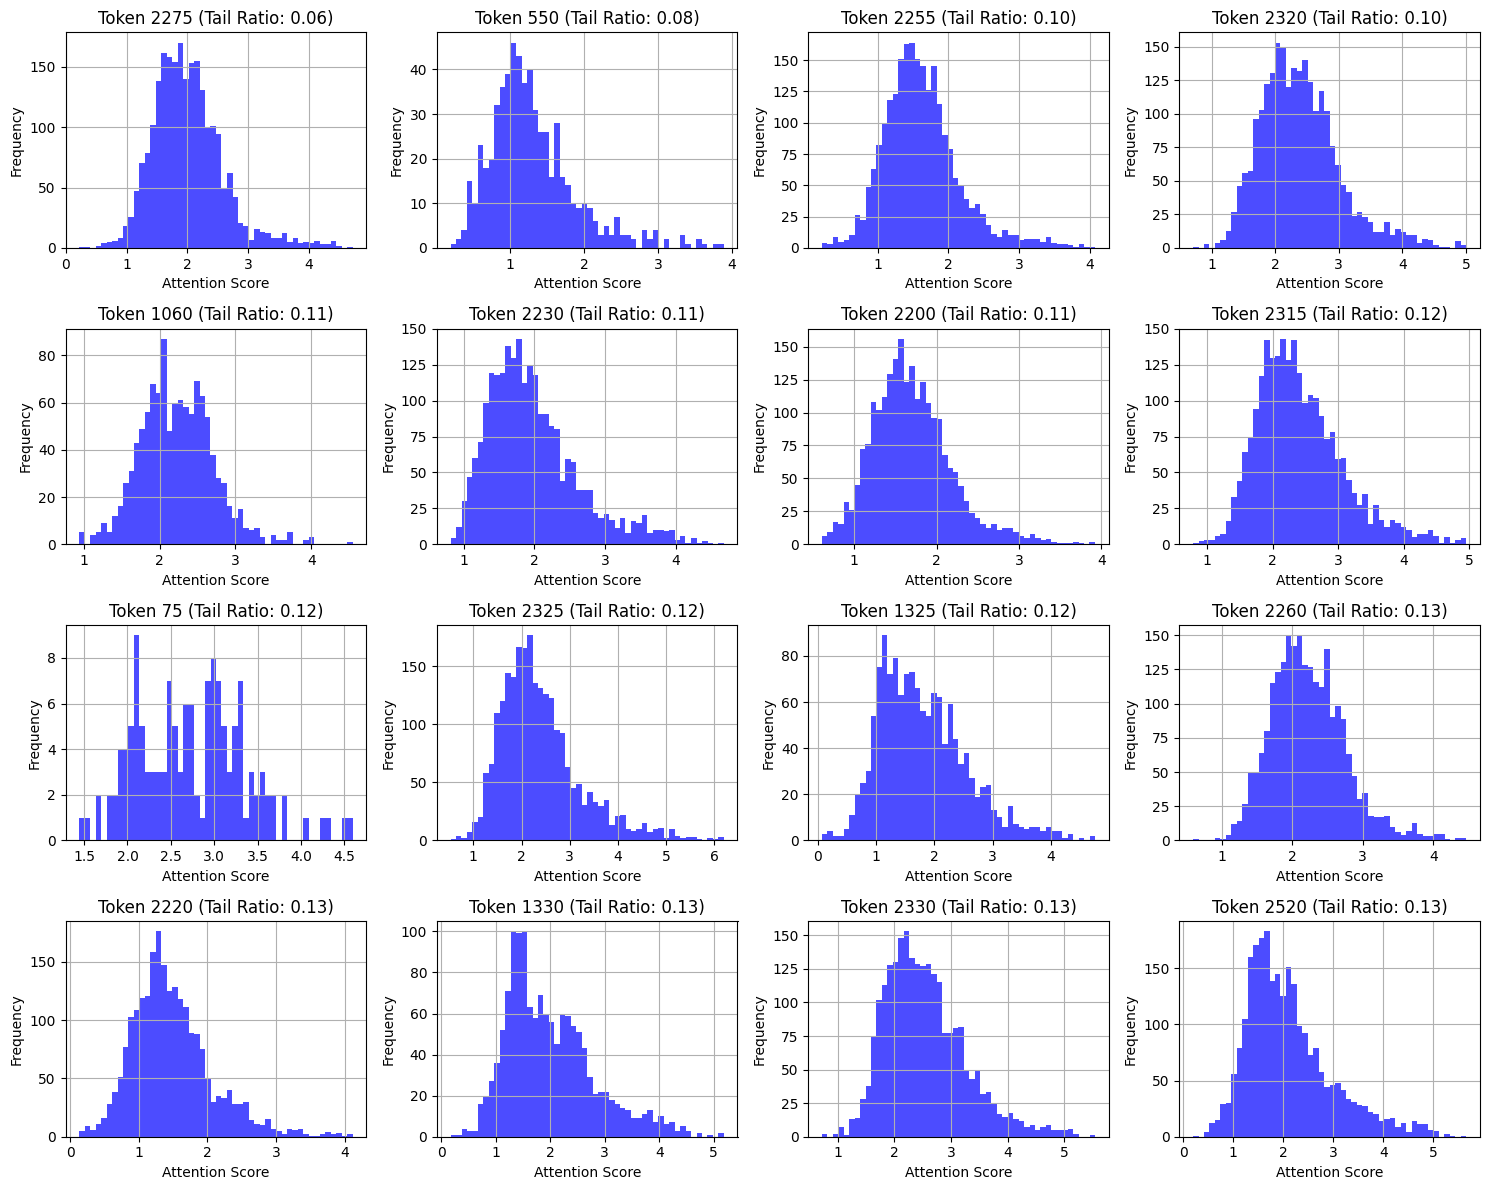

In [49]:
fig, axes = plt.subplots(4, 4, figsize=(15, 12))

for i, token in enumerate(least_k["token"]):
    stats = observer.get_stats_at_token(token)[20]
    scores = None
    for head in range(heads):
        if scores is None:
            scores = stats[head]["scores"]
        else:
            scores += stats[head]["scores"]
    scores = scores / heads

    axes[i // 4, i % 4].hist(scores.cpu().numpy(), bins=50, color="blue", alpha=0.7)
    axes[i // 4, i % 4].set_title(f"Token {token} (Tail Ratio: {results.loc[results['token'] == token, 'tail_ratio'].values[0]:.2f})")
    axes[i // 4, i % 4].set_xlabel("Attention Score")
    axes[i // 4, i % 4].set_ylabel("Frequency")
    axes[i // 4, i % 4].grid()
plt.tight_layout()
plt.show()

### After Softmax

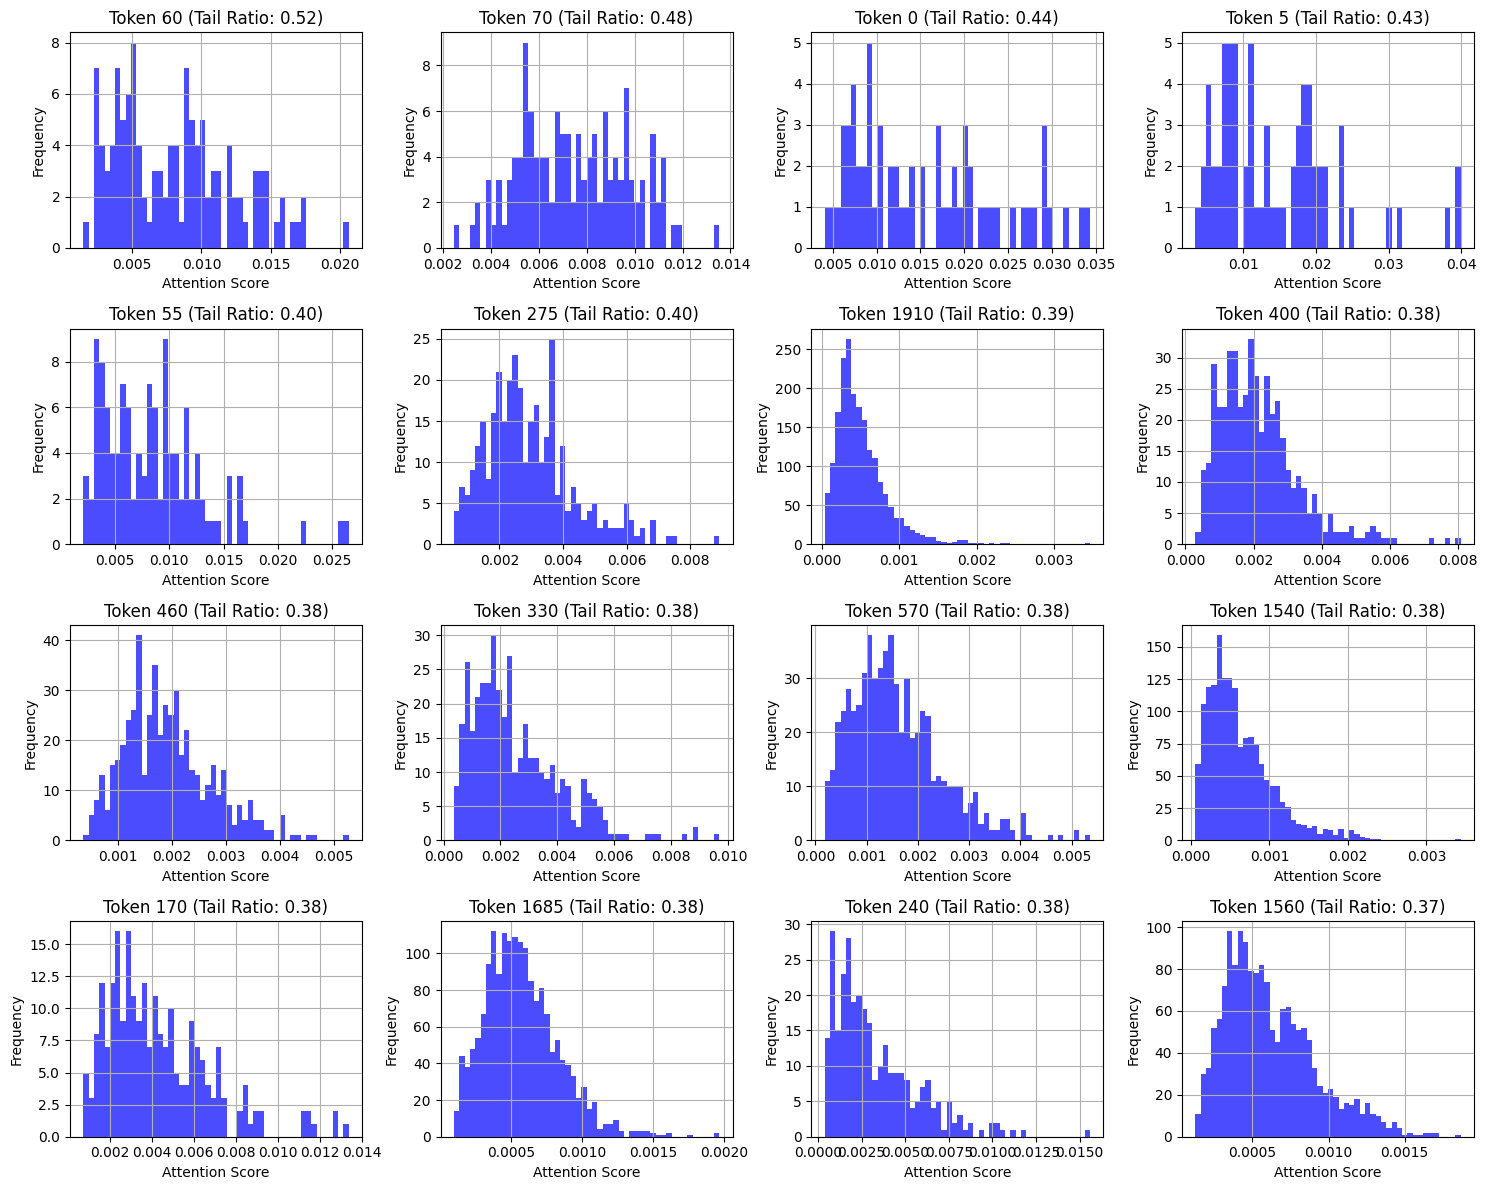

In [70]:
fig, axes = plt.subplots(4, 4, figsize=(15, 12))

for i, token in enumerate(top_k["token"]):
    stats = observer.get_stats_at_token(token)[20]
    scores = None
    for head in range(heads):
        if scores is None:
            scores = stats[head]["scores"]
        else:
            scores += stats[head]["scores"]
    scores = scores / heads
    
    scores = torch.softmax(scores, dim=0)

    axes[i // 4, i % 4].hist(scores.cpu().numpy(), bins=50, color="blue", alpha=0.7)
    axes[i // 4, i % 4].set_title(f"Token {token} (Tail Ratio: {results.loc[results['token'] == token, 'tail_ratio'].values[0]:.2f})")
    axes[i // 4, i % 4].set_xlabel("Attention Score")
    axes[i // 4, i % 4].set_ylabel("Frequency")
    axes[i // 4, i % 4].grid()
plt.tight_layout()
plt.show()

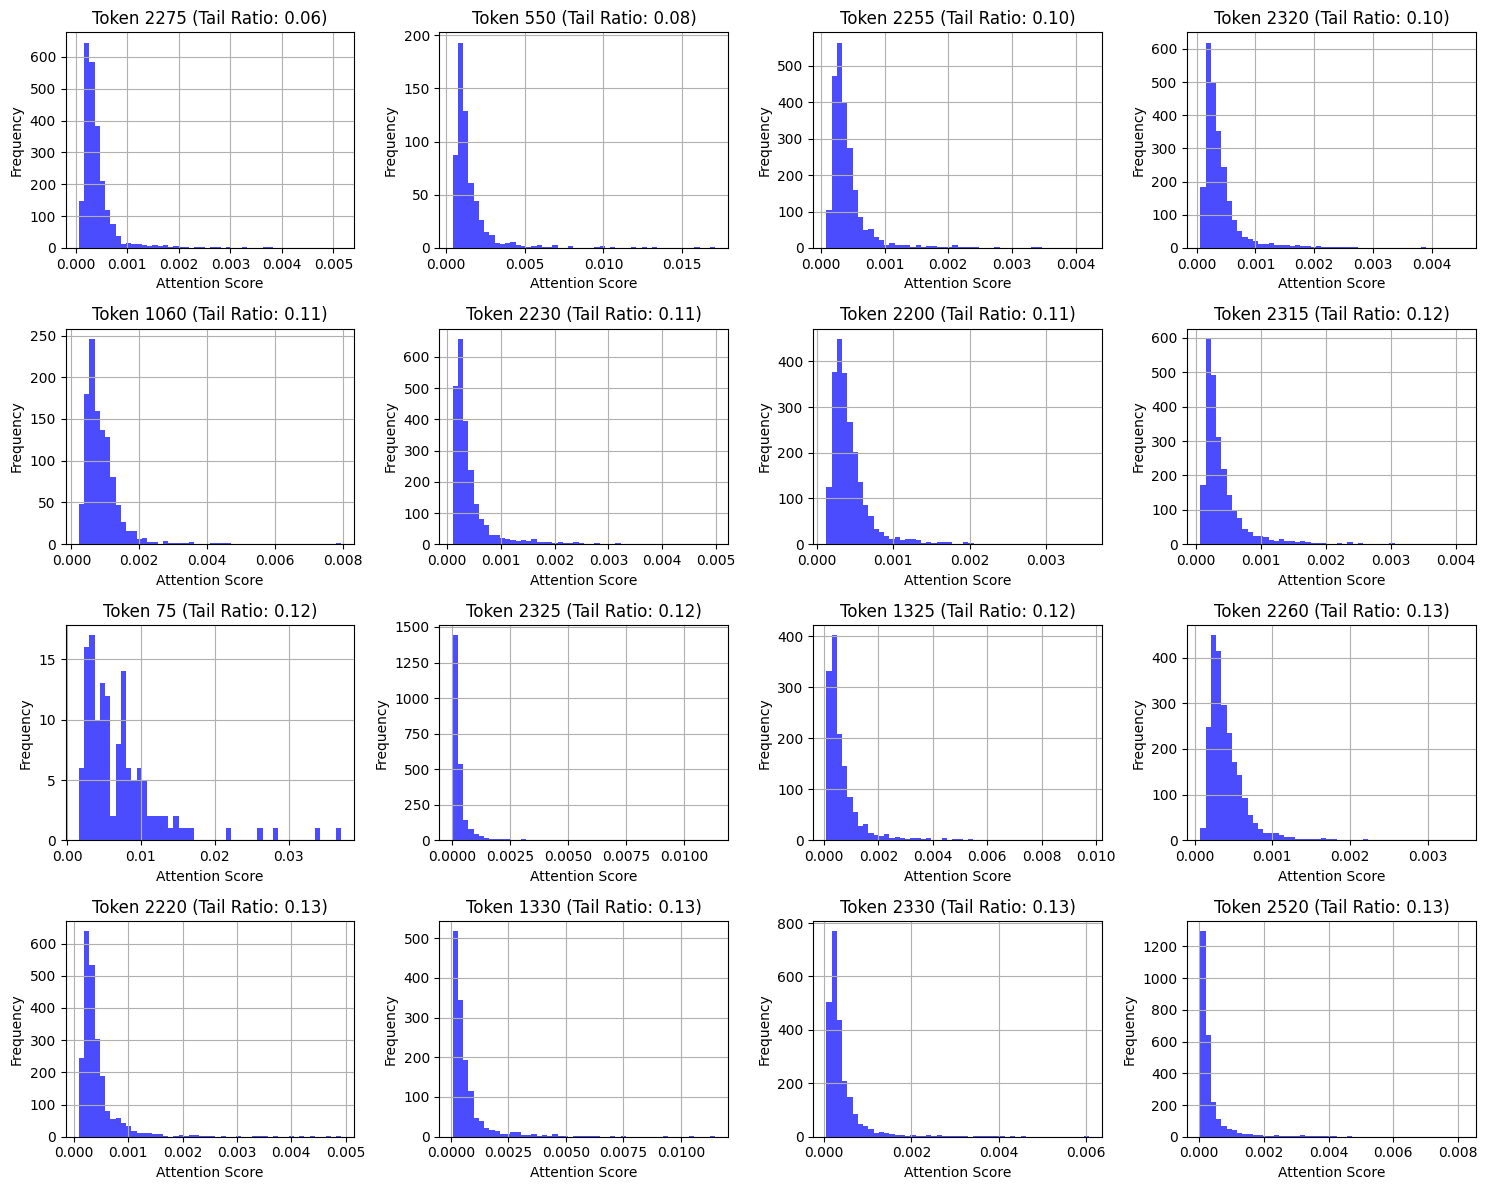

In [68]:
fig, axes = plt.subplots(4, 4, figsize=(15, 12))

for i, token in enumerate(least_k["token"]):
    stats = observer.get_stats_at_token(token)[20]
    scores = None
    for head in range(heads):
        if scores is None:
            scores = stats[head]["scores"]
        else:
            scores += stats[head]["scores"]
    scores = scores / heads
    scores = torch.softmax(scores, dim=0)

    axes[i // 4, i % 4].hist(scores.cpu().numpy(), bins=50, color="blue", alpha=0.7)
    axes[i // 4, i % 4].set_title(f"Token {token} (Tail Ratio: {results.loc[results['token'] == token, 'tail_ratio'].values[0]:.2f})")
    axes[i // 4, i % 4].set_xlabel("Attention Score")
    axes[i // 4, i % 4].set_ylabel("Frequency")
    axes[i // 4, i % 4].grid()
plt.tight_layout()
plt.show()

### K-means clusters

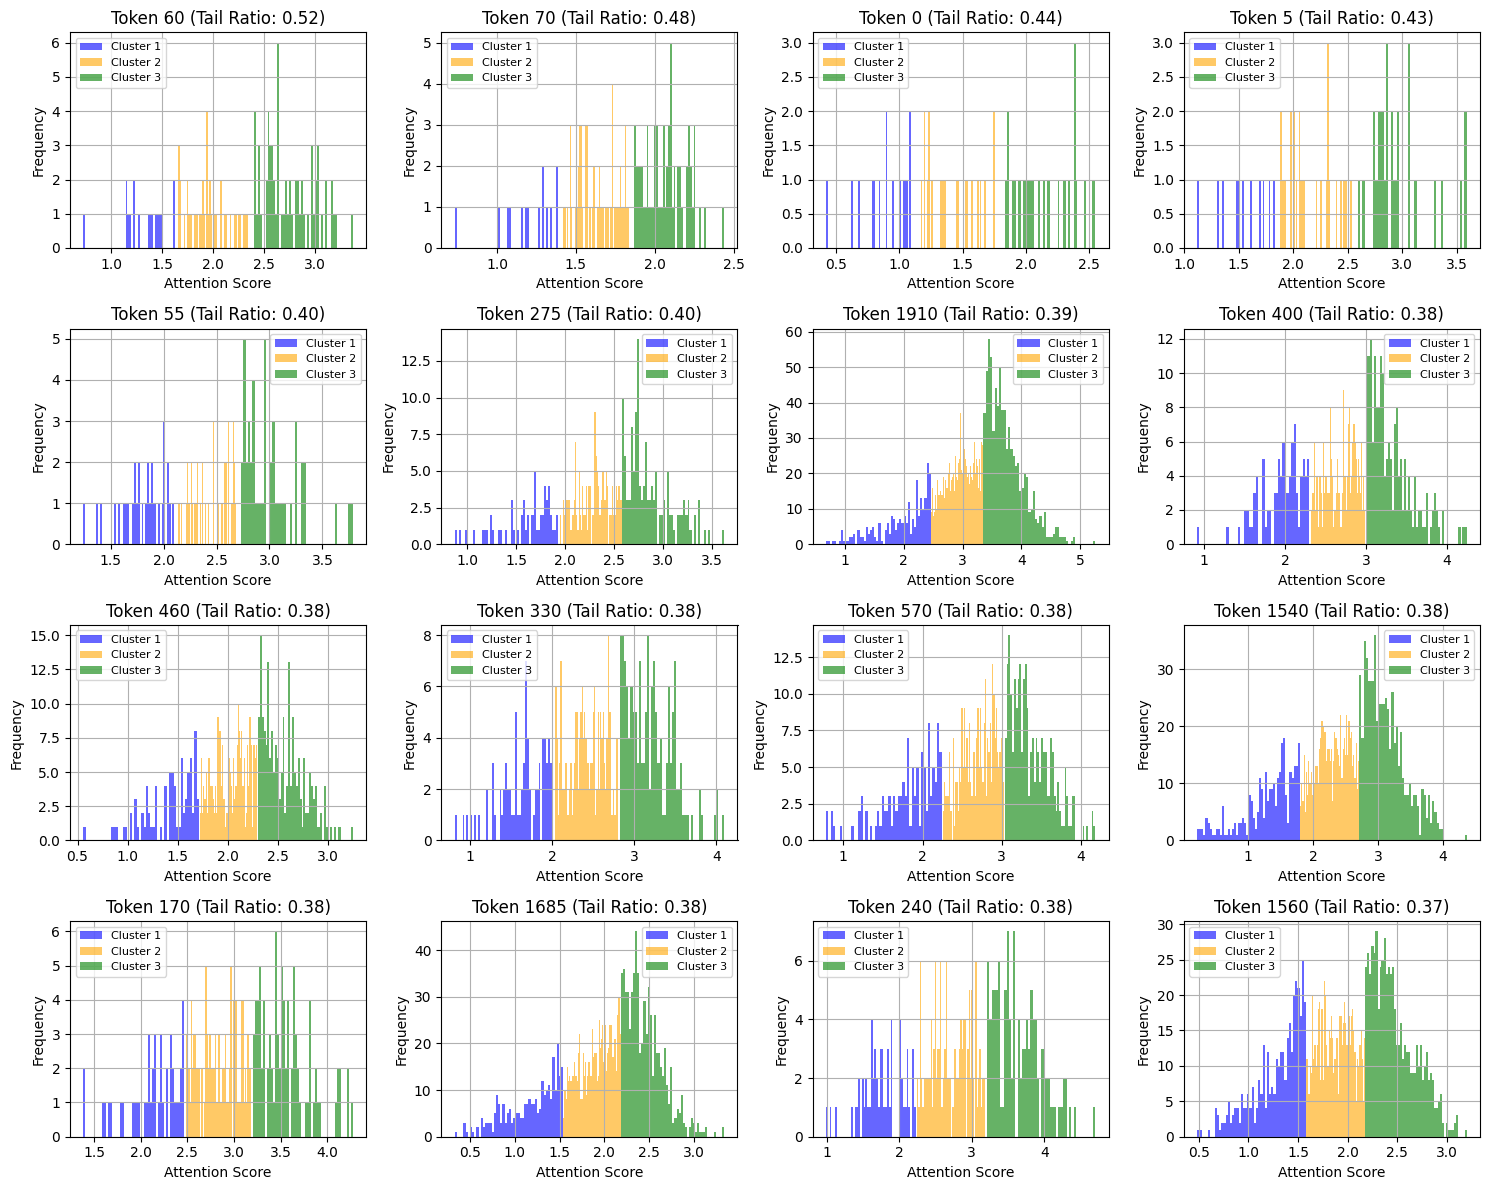

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(15, 12))

colors = ["blue", "orange", "green"]

for i, token in enumerate(top_k["token"]):
    stats = observer.get_stats_at_token(token)[20]
    scores = None
    for head in range(heads):
        if scores is None:
            scores = stats[head]["scores"]
        else:
            scores += stats[head]["scores"]
    scores = scores / heads

    # Apply KMeans clustering
    scores_np = scores.detach().cpu().numpy().reshape(-1, 1)
    km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(scores_np)
    labels = km.labels_
    centers = km.cluster_centers_.flatten()

    # Sort clusters by center value for consistent coloring
    cluster_order = np.argsort(centers)

    # Plot histogram with different colors for each cluster
    for cluster_idx in range(3):
        original_cluster = cluster_order[cluster_idx]
        cluster_data = scores_np[labels == original_cluster].flatten()
        axes[i // 4, i % 4].hist(
            cluster_data,
            bins=50,
            color=colors[cluster_idx],
            alpha=0.6,
            label=f"Cluster {cluster_idx+1}",
        )

    axes[i // 4, i % 4].set_title(
        f"Token {token} (Tail Ratio: {results.loc[results['token'] == token, 'tail_ratio'].values[0]:.2f})"
    )
    axes[i // 4, i % 4].set_xlabel("Attention Score")
    axes[i // 4, i % 4].set_ylabel("Frequency")
    axes[i // 4, i % 4].legend(fontsize=8)
    axes[i // 4, i % 4].grid()

plt.tight_layout()
plt.show()

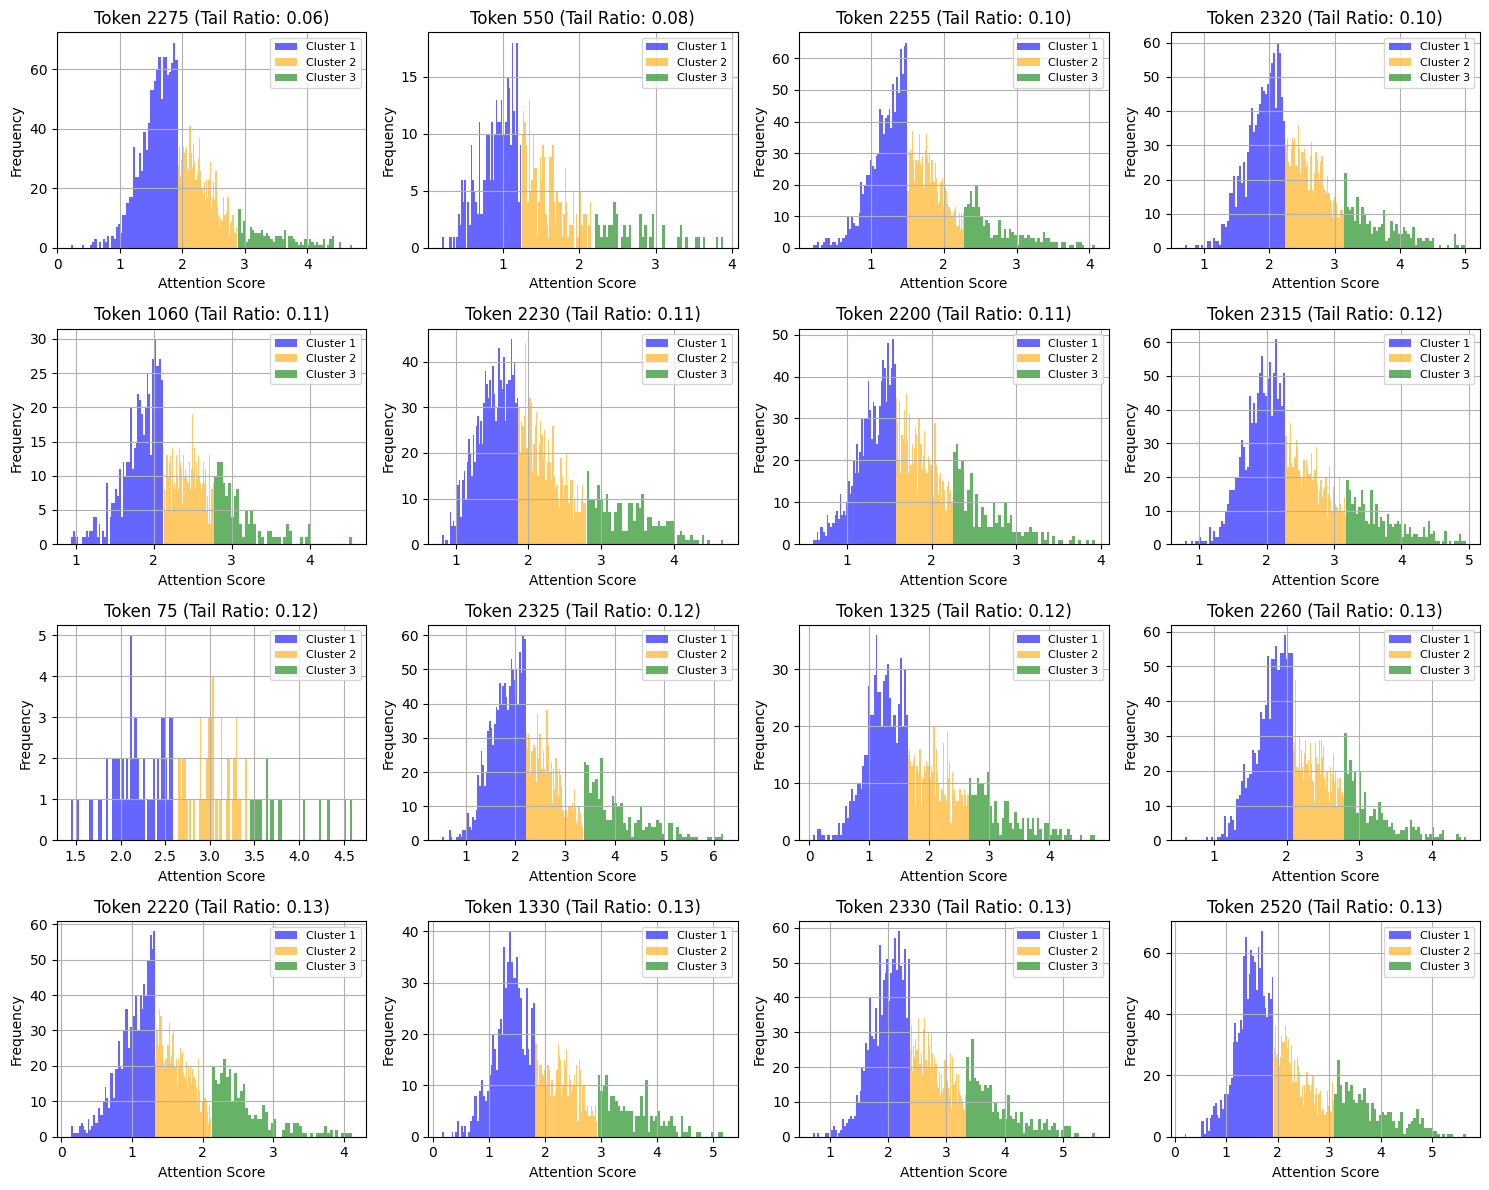

In [73]:
fig, axes = plt.subplots(4, 4, figsize=(15, 12))

colors = ["blue", "orange", "green"]

for i, token in enumerate(least_k["token"]):
    stats = observer.get_stats_at_token(token)[20]
    scores = None
    for head in range(heads):
        if scores is None:
            scores = stats[head]["scores"]
        else:
            scores += stats[head]["scores"]
    scores = scores / heads

    # Apply KMeans clustering
    scores_np = scores.detach().cpu().numpy().reshape(-1, 1)
    km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(scores_np)
    labels = km.labels_
    centers = km.cluster_centers_.flatten()

    # Sort clusters by center value for consistent coloring
    cluster_order = np.argsort(centers)

    # Plot histogram with different colors for each cluster
    for cluster_idx in range(3):
        original_cluster = cluster_order[cluster_idx]
        cluster_data = scores_np[labels == original_cluster].flatten()
        axes[i // 4, i % 4].hist(
            cluster_data,
            bins=50,
            color=colors[cluster_idx],
            alpha=0.6,
            label=f"Cluster {cluster_idx+1}",
        )

    axes[i // 4, i % 4].set_title(
        f"Token {token} (Tail Ratio: {results.loc[results['token'] == token, 'tail_ratio'].values[0]:.2f})"
    )
    axes[i // 4, i % 4].set_xlabel("Attention Score")
    axes[i // 4, i % 4].set_ylabel("Frequency")
    axes[i // 4, i % 4].legend(fontsize=8)
    axes[i // 4, i % 4].grid()

plt.tight_layout()
plt.show()

Debug k-means clustering:

In [107]:
# Apply KMeans clustering
arr = np.array([1, 2, 3, 4, 5, 6, 20, 21, 22, 23, 24, 1002]).reshape(-1, 1)
km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(arr)
labels = km.labels_
centers = km.cluster_centers_.flatten()

# Sort clusters by center value for consistent coloring
cluster_order = np.argsort(centers)

# show insights
print("Cluster labels:", labels)
print("Cluster centers:", centers)
print("Cluster order (by center value):", cluster_order)

Cluster labels: [2 2 2 2 2 2 0 0 0 0 0 1]
Cluster centers: [  22.  1002.     3.5]
Cluster order (by center value): [2 0 1]
